UNSTABLE EIGENVALUES DETECTED FOR h = 0.01
UNSTABLE EIGENVALUES DETECTED FOR h = 0.1
UNSTABLE EIGENVALUES DETECTED FOR h = 0.5
UNSTABLE EIGENVALUES DETECTED FOR h = 1.0


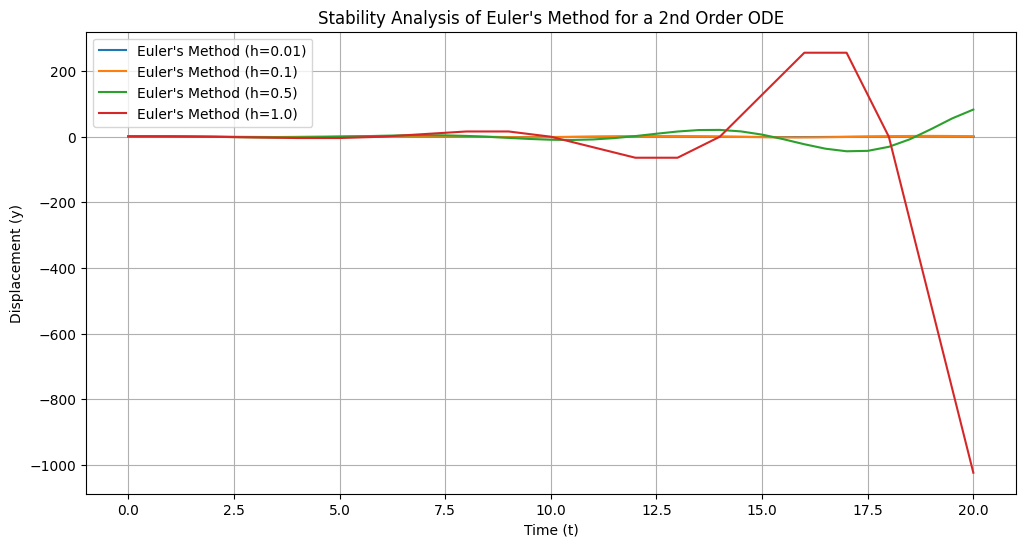

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# Parameters
k = 1.0        # Spring constant
h_values = [0.01, 0.1, 0.5, 1.0]  # Different step sizes to test stability
t_start = 0    # Start time
t_end = 20     # End time
y_0 = 1.0      # Initial displacement
v_0 = 0.0      # Initial velocity
# Function to apply Euler's Method for given step size


def check_stability(arr):
    isUnstable = False
    for num in arr:
        if (abs(num) > 1):
            isUnstable = True

    return isUnstable

A_matrices = np.array([])

for i in range(len(h_values)):
    A = np.matrix([[0,1], [-k,0]]) # Equivalent Diff Eq is y^2 + ky = 0
    A = np.eye(2) - A@(np.diag(np.array([h_values[i], h_values[i]])))
    A_matrices = np.append(A_matrices, A)
    if (check_stability(np.linalg.eig(A)[0])):
        print ("UNSTABLE EIGENVALUES DETECTED FOR h =", h_values[i])
    else:
        print ("Stable for h =", h_values[i])

def euler_method(h, k, t_start, t_end, y_0, v_0):
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    v_values = np.zeros(len(t_values))    
    # Set initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    for i in range(1, len(t_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]        
        # Update equations for Euler's Method
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)   
    return t_values, y_values
# Plot results for different step sizes
plt.figure(figsize=(12, 6))

for h in h_values:
    t, y = euler_method(h, k, t_start, t_end, y_0, v_0)
    plt.plot(t, y, label=f'Euler\'s Method (h={h})')
plt.xlabel('Time (t)')
plt.ylabel('Displacement (y)')
plt.title('Stability Analysis of Euler\'s Method for a 2nd Order ODE')
plt.legend()
plt.grid(True)
plt.show()